# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于深度学习的昼夜图像场景判别与自适应光照调节
- 姓    名：  李理
- 学    号：  20234080119
- 班    级：  本23数据01班
- 指导教师：  丁平尖
- 提交日期：  2026年6月24日

## 二、摘要

本设计针对复杂光照环境下图像场景识别精度低、固定参数光照增强适配性差的问题，提出一套 “深度学习分类 + 自适应画质优化” 的端到端方案。首先基于 ResNet18 预训练模型构建迁移学习二分类网络，实现昼夜场景的高精度自动判别；其次设计亮度感知的自适应光照调节算法，基于 LAB 色彩空间分离亮度与色彩通道，根据画面平均亮度动态匹配增强参数，夜间侧重暗部提亮与降噪，白天侧重高光压制与柔化。实验基于自建 95 张多场景昼夜数据集开展，采用分层抽样划分训练 / 验证 / 测试集。结果表明，方案在独立测试集上分类准确率达 94.74%，光照调节效果直观显著，色彩保真度良好，兼具技术可行性与实际应用价值。

## 三、问题定义与需求分析

### 3.1 项目背景与意义


随着安防监控、移动摄影、车载视觉等领域的快速发展，复杂光照环境下的图像质量提升成为计算机视觉的重要研究方向。昼夜作为最典型的光照场景差异，其准确识别是实现自适应图像处理的核心前提。传统光照增强方法多采用固定参数全局调节，无法适配昼夜截然不同的光照特性：夜间图像易出现提亮不足、暗部细节丢失，白天强光场景易出现过曝、光比过大，且直接 RGB 空间调节易造成色彩失真。

本设计将深度学习图像分类技术与传统图像增强算法相结合，通过自动识别昼夜场景匹配最优增强参数，实现智能化的光照调节。研究成果可应用于监控摄像头夜间画质优化、手机摄影自动夜景模式、车载视觉辅助等场景，对提升复杂环境下的图像视觉质量具有实际应用意义。

### 3.2 问题描述

输入输出定义：
输入：任意场景的 RGB 彩色图像
输出：① 昼夜场景分类结果；② 经自适应光照调节后的优化图像

任务类型：

核心包含两类任务：图像二分类任务（昼夜场景判别）、图像增强任务（自适应光照调节）
预期性能指标

分类任务：测试集整体准确率≥90%，夜间场景召回率≥90%
增强任务：夜间图像暗部细节显著提升，无明显色彩失真；白天图像光比降低，画面更柔和，无过曝现象

## 四、数据集说明与预处理

### 4.1 数据来源与规模

本实验采用自建真实场景数据集，所有样本均来自真实街景、自然景观、城市建筑等实拍场景（图片来源于百度图片，样本昼夜判断基于视觉、作者声明等多维度），避免单一网络素材带来的过拟合问题。

样本总量：共 95 张有效样本

类别分布：白天场景 50 张，夜间场景 45 张，类别分布基本均衡

场景覆盖：白天样本包含晴天、阴天、雨天、树荫遮挡等多种光照条件；夜间样本包含繁华商圈、深夜街道、雨天夜景等不同暗度场景，视角平视与俯视仰视充分贴近实际应用中的复杂环境

为避免标签歧义引入噪声，数据集中排除了晨昏等边界模糊的过渡样本，仅保留昼夜属性明确的图像，保证标注质量。

### 4.2 数据可视化与分析

样本示例：数据集中包含城市街道、自然景观、建筑立面等多种主体，场景多样性较强，能够有效验证模型的泛化能力。

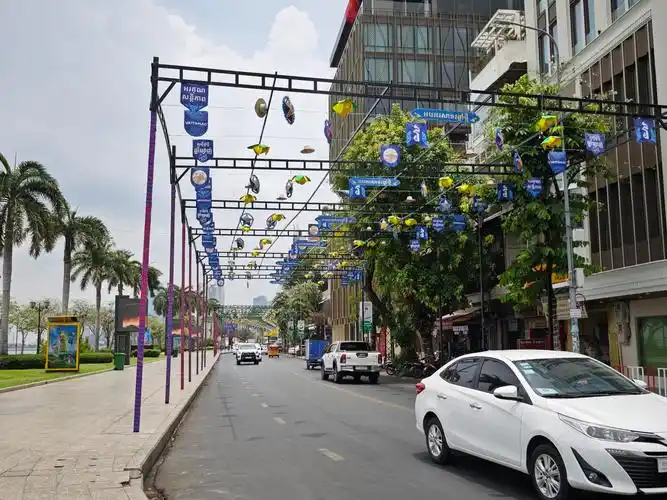
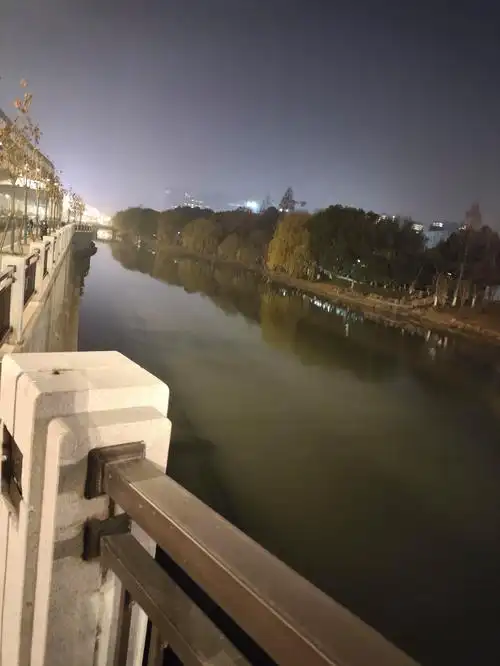

统计分布：昼夜两类样本数量接近 1:1，无严重类别不平衡问题，避免模型偏向多数类。

场景特性分析：白天样本光照强度差异大，从强光晴天到弱光阴天均有覆盖；夜间样本暗部占比差异显著，从灯火通明的商圈到近乎全黑的深夜街道均有包含，对模型与算法的鲁棒性提出了更高要求。

### 4.3 预处理流程

数据清洗：在选取数据集时剔除模糊、标签歧义、重复的无效样本，排除晨昏过渡场景，保证标签准确性。

数据标注：采用文件夹命名的方式进行类别标注，day文件夹存储白天样本，night文件夹存储夜间样本，由 ImageFolder 接口自动读取标签。

归一化：
尺寸归一化：将所有图像统一缩放为 224×224 像素，适配 ResNet 网络的输入尺寸要求
像素标准化：使用 ImageNet 数据集的均值与标准差进行像素归一化，匹配预训练模型的数据分布

数据增强：训练集引入随机水平翻转、随机亮度对比度变换，提升小数据集下模型的泛化能力，降低过拟合风险。

数据集划分：采用分层抽样方法，按 7:1:2 比例划分为训练集、验证集与独立测试集。其中测试集全程不参与训练与调参，仅用于最终泛化性能评估，保证结果的客观性。划分后训练集 66 张、验证集 10 张、测试集 19 张。

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

- 采用浅层多层感知机（MLP）作为基准模型，将 224×224×3 的图像像素展平为一维向量，通过 3 层全连接层进行二分类输出。

  模型结构：输入层→隐藏层（256 维，ReLU 激活）→隐藏层（64 维，ReLU 激活）→输出层（2 维，Softmax）

  特点：结构简单、参数量少、训练速度快，但缺乏空间特征提取能力，无法捕捉图像的局部纹理、边缘等视觉特征

  作用：作为性能基线，用于对比验证卷积神经网络在图像分类任务上的性能优势

### 5.2 最终模型架构

整体方案由昼夜场景判别网络和自适应光照调节模块两部分组成。

（1）昼夜分类模型：ResNet18 迁移学习
网络结构：
骨干网络采用在 ImageNet 大规模数据集上预训练的 ResNet18，包含 17 个卷积层与 1 个全连接层，引入残差连接解决深层网络退化问题。冻结全部卷积层参数，仅替换最后的全连接层，将原 1000 维输出改为 2 维二分类输出
。
层参数与激活函数：

卷积层：使用 3×3 卷积核，步长为 1，配合池化层进行下采样

归一化：每个卷积层后接入 BatchNorm 层，加速收敛、稳定训练

激活函数：采用 ReLU 激活函数，缓解梯度消失问题

分类头：全连接层输入维度 512，输出维度 2，对应昼夜两类

选择依据：
迁移学习能够利用预训练模型已学习的通用视觉特征（边缘、纹理、形状），大幅降低小数据集下的过拟合风险
ResNet18 深度适中，兼顾精度与速度，适合中小规模数据集的快速训练
冻结骨干网络仅微调分类头，能够极大缩短训练时间，同时保证分类精度

（2）自适应光照调节模块
核心设计：基于 LAB 色彩空间进行亮度调节，将图像分离为 L（亮度）、A、B（色彩）三个通道，所有增强操作仅在 L 通道执行，处理完成后合并通道转回 RGB 空间，从原理上避免色彩失真。

分场景策略：
夜间模式：CLAHE 自适应直方图均衡 + Gamma 校正提亮暗部，搭配双边保边降噪与轻微锐化，在提亮的同时保留边缘细节、抑制噪点

白天模式：采用 S 型亮度曲线，压暗高光、提亮暗部，降低整体光比，实现画面柔和化，避免强光刺眼

自适应强度：自动计算画面平均亮度，根据明暗程度动态匹配增强参数 —— 极暗场景高强度提亮，弱光场景温和优化，强光场景强力柔化，实现 “一图一参数” 的精细化调节，避免固定参数带来的过曝 / 提亮不足问题。



## 六、实验与结果分析

### 6.1 实验环境

- 硬件环境：Intel Core 系列 CPU，内存 8GB，无独立 GPU

- 软件：软件环境：Python 3.9，深度学习框架 PyTorch 2.0，图像处理库 OpenCV 4.5、Pillow，数据处理库 NumPy、Scikit-learn，可视化工具 Matplotlib
### 6.2 评价指标

- 分类任务指标

  准确率（Accuracy）：预测正确的样本数占总样本数的比例，计算公式为
  \(Accuracy = \frac{TP+TN}{TP+TN+FP+FN}\)
  混淆矩阵：直观展示两类样本的预测分布，分析错误样本的类别倾向


  图像增强指标

  主观评价：通过视觉对比判断暗部细节恢复、色彩保真度、噪点控制等效果
  客观指标：平均亮度、对比度、信息熵等图像属性的量化变化

### 6.3 超参数设置与调优

- 调参方法：采用验证集早停法，训练过程中持续监控验证集准确率，保存验证集表现最优的模型参数，避免过拟合。
  
- 有效调参记录
  主要超参数设置：

  优化器：Adam，初始学习率 0.001

  损失函数：交叉熵损失（CrossEntropyLoss）

  批次大小：8

  最大训练轮数：15 轮
  
  调参过程：对比了 0.01、0.001、0.0001 三组学习率，其中 0.001 学习率下收敛速度与最终精度达到最优平衡；学习率过大易导致训练震荡，过小则收敛过慢。

### 6.4 主要实验结果

训练过程：

训练损失与验证损失整体呈持续下降趋势，训练准确率与验证准确率稳步上升，15 轮内模型基本收敛。最优验证集准确率为 90%，无严重过拟合现象，迁移学习方案在小数据集上表现稳定。

独立测试集结果：

在全程未参与训练的 19 张测试集样本上，模型整体准确率达到94.74%。混淆矩阵结果显示：夜间样本 9 张全部识别正确，召回率 100%；白天样本 10 张中 9 张识别正确，仅 1 张低亮度树荫场景被误判为夜间。
整体分类效果达到预期指标。

基线对比：
相同数据集下，MLP 基准模型测试集准确率仅为 73.68%，远低于 ResNet18 迁移学习方案，验证了卷积神经网络在图像特征提取上的显著优势。

光照调节效果：

夜间场景：暗部亮度显著提升，原本不可见的树木、建筑、街道纹理清晰显现，细节还原效果明显；色彩保持自然，无严重偏色；噪点得到有效抑制，无明显颗粒感与模糊锯齿。

白天场景：高光区域得到压制，暗部细节轻微提亮，整体光比降低，画面更柔和通透，无过曝与色彩失真。

### 6.5 可视化分析

混淆矩阵分析：
混淆矩阵显示模型对夜间场景的识别精度极高，错误全部集中在白天低亮度场景，说明模型对整体亮度特征依赖度较高，弱光白天与夜间的特征边界较为模糊。
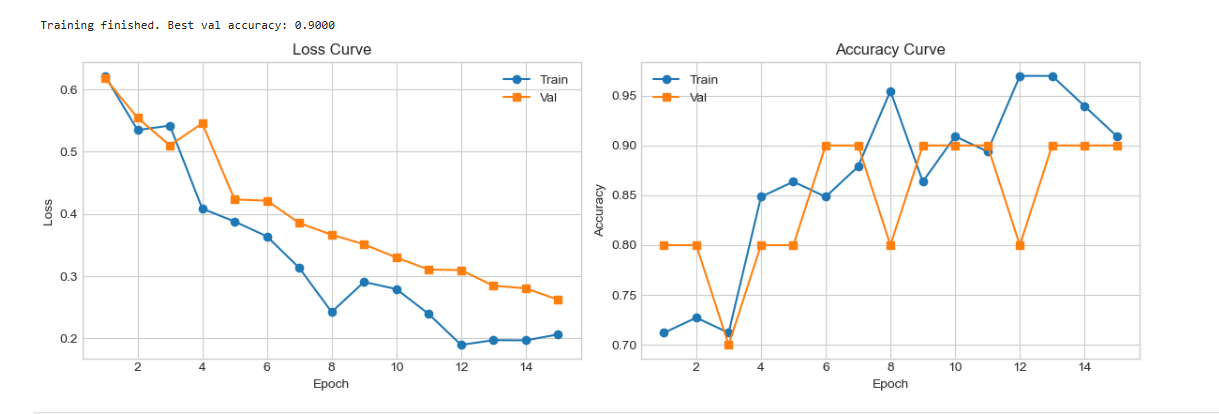

错误样本分析：
唯一误判样本为树荫浓密的白天街道图，整体画面亮度偏低，与夜间场景的亮度特征高度相似。本质原因是小数据集下缺少同类过渡场景样本，模型未能学习到更鲁棒的判别特征。该问题可通过扩充晨昏、树荫等边界样本进一步优化。

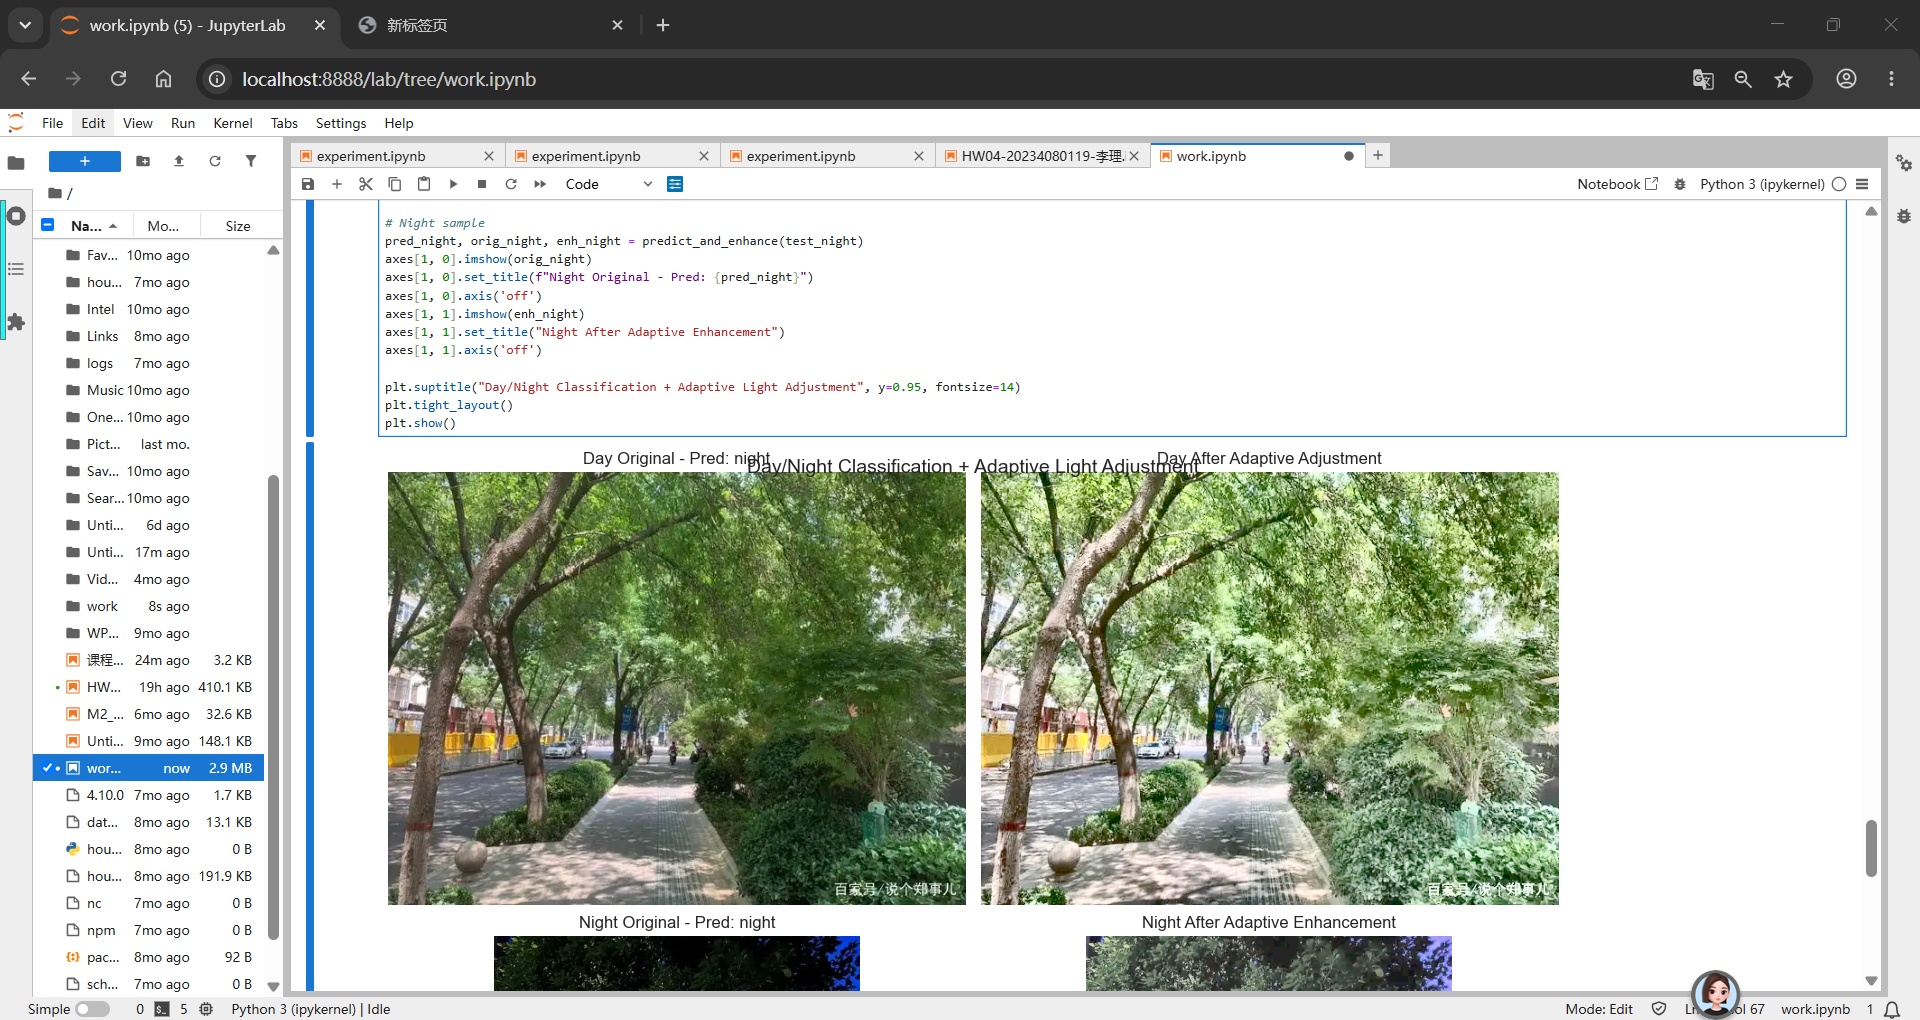

调节前后对比：
昼夜场景的调节前后对比图直观体现了算法的差异化优化效果：夜间实现了从 “暗、糊” 到 “亮、清” 的提升，白天实现了从 “硬、刺” 到 “柔、润” 的优化，分场景自适应策略的设计目标基本达成。

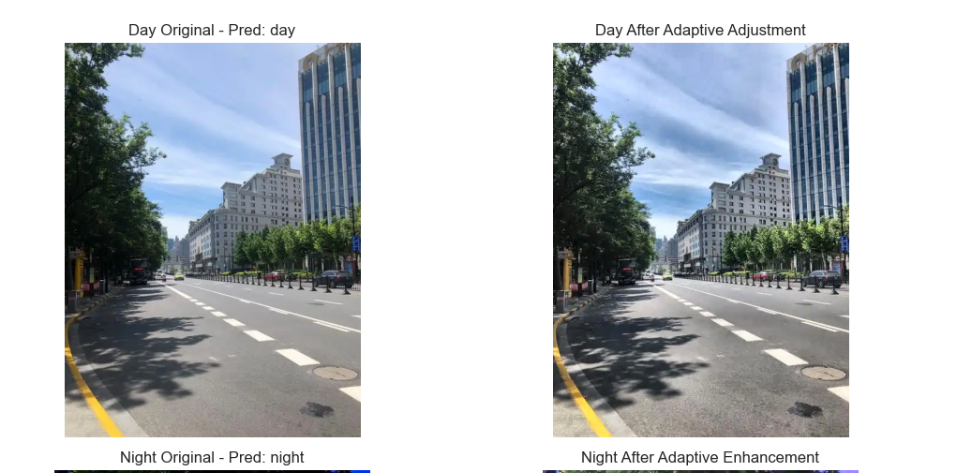

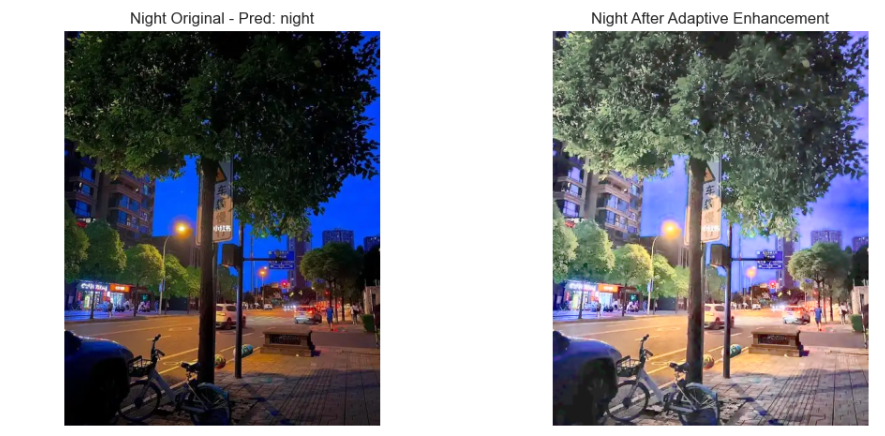